C:\Users\alefe\AppData\Local\Temp\ipykernel_13980\450361016.py:14: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)
C:\Users\alefe\AppData\Local\Temp\ipykernel_13980\450361016.py:50: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  mes_recomendado = int(mejor_mes[mejor_mes["cripto_id"]==cripto]["mes"])
C:\Users\alefe\AppData\Local\Temp\ipykernel_13980\450361016.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  precio_recomendado = float(mejor_mes[mejor_mes["cripto_id"]==cripto]["cierre"])


Recomendación de compra por mes (basada en promedio histórico de precios):

   cripto_id  mes         cierre
0        BTC    1  217160.150342
14      DOGE    3  118579.064516
27       NEO    4  120043.058333
36       UNI    1  291452.155039
49       ZEN    2  130450.769912


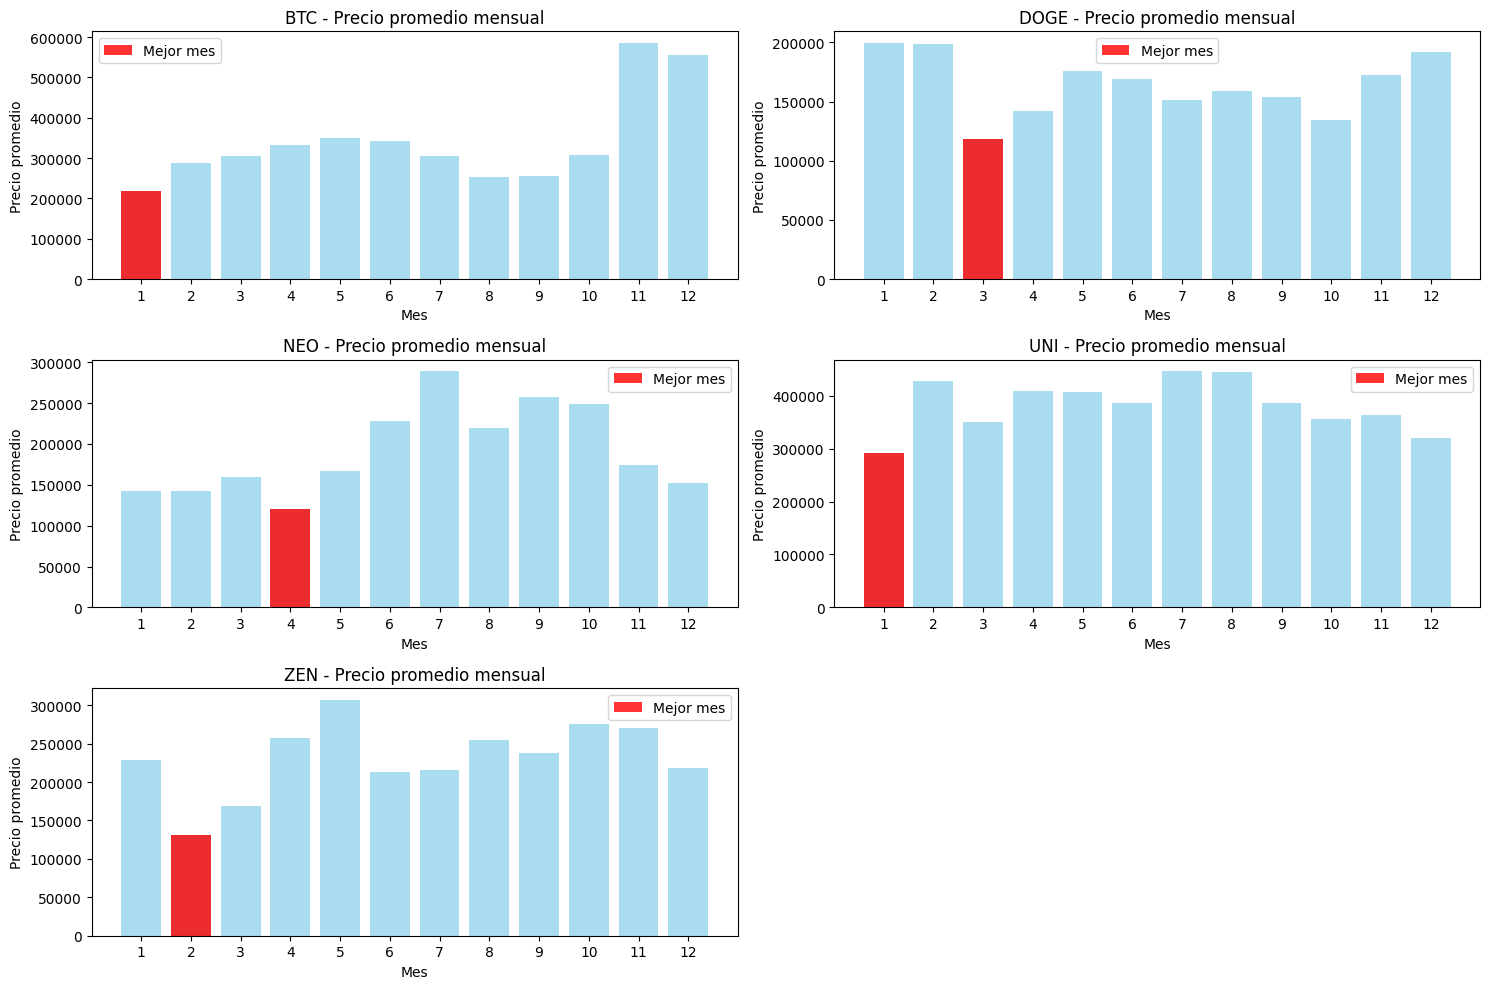


Recomendaciones mensuales guardadas en: ../datos/procesados/recomendacion_mensual.csv


In [1]:
# 05_recomendacion_mensual.ipynb
# Recomendación de compra por mes para cada criptomoneda basada en estadísticas históricas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# -----------------------------
# 1. Cargar dataset unificado
# -----------------------------
ruta_csv = "../datos/procesados/precios_diarios.csv"
df = pd.read_csv(ruta_csv, encoding="utf-8", sep=';')
df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)

# -----------------------------
# 2. Agregar columna mes y año
# -----------------------------
df["año"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month

# Filtrar hasta 2026
df = df[df["año"] <= 2026]

# -----------------------------
# 3. Calcular promedio mensual por cripto
# -----------------------------
promedio_mensual = df.groupby(["cripto_id", "mes"])["cierre"].mean().reset_index()

# -----------------------------
# 4. Determinar mejor mes para comprar cada cripto
# -----------------------------
# Mejor mes = mes con el precio promedio mínimo (históricamente más barato)
mejor_mes = promedio_mensual.loc[promedio_mensual.groupby("cripto_id")["cierre"].idxmin()]
mejor_mes = mejor_mes.sort_values("cripto_id")

print("Recomendación de compra por mes (basada en promedio histórico de precios):\n")
print(mejor_mes[["cripto_id","mes","cierre"]])

# -----------------------------
# 5. Graficar precios promedio por mes y marcar mejor mes
# -----------------------------
plt.figure(figsize=(15,10))
for i, cripto in enumerate(df["cripto_id"].unique(), 1):
    plt.subplot(3,2,i)  # subplot 3x2
    subset = promedio_mensual[promedio_mensual["cripto_id"]==cripto]
    plt.bar(subset["mes"], subset["cierre"], color="skyblue", alpha=0.7)
    
    # marcar el mes recomendado
    mes_recomendado = int(mejor_mes[mejor_mes["cripto_id"]==cripto]["mes"])
    precio_recomendado = float(mejor_mes[mejor_mes["cripto_id"]==cripto]["cierre"])
    plt.bar(mes_recomendado, precio_recomendado, color="red", alpha=0.8, label="Mejor mes")
    
    plt.title(f"{cripto} - Precio promedio mensual")
    plt.xlabel("Mes")
    plt.ylabel("Precio promedio")
    plt.xticks(range(1,13))
    plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 6. Guardar resultados
# -----------------------------
ruta_recomendacion = "../datos/procesados/recomendacion_mensual.csv"
mejor_mes.to_csv(ruta_recomendacion, index=False, encoding="utf-8", sep=';')
print(f"\nRecomendaciones mensuales guardadas en: {ruta_recomendacion}")
